In [1]:
#del F
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
import matplotlib.pyplot as plt
import torch.optim.swa_utils as swa_utils

import operator
from functools import reduce
from functools import partial
from timeit import default_timer
from utilities3 import *
import pickle
import torch.optim as optim
import os
from tqdm import tqdm

from Adam import Adam

from torch.optim import Adam as adam
torch.manual_seed(2)
np.random.seed(2)

if torch.cuda.is_available():
    print("CUDA is available. GPU will be used.")
    device = torch.device('cuda:0')
else:
    print("CUDA is not available. CPU will be used.")
    device = torch.device('cpu')

CUDA is available. GPU will be used.


In [2]:
torch.cuda.is_available()

True

Vanila $\psi$- FNO

In [3]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_high):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_high = modes_high  #Number of Fourier modes to multiply, at most floor(N/2) + 1
        
        self.scale = (1 / (in_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes_high, dtype=torch.cfloat))
    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        if len(input.shape) == 3:
            return torch.einsum("bix,iox->box", input, weights)
        elif len(input.shape) == 4:
            return torch.einsum("dbix,iox->dbox", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        Nt= x.shape[1]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        if len(x.shape) == 3:
            out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat)
            out_ft[:, :,:self.modes_high:] = self.compl_mul1d(x_ft[:, :, :self.modes_high], self.weights)
        elif len(x.shape) == 4:
            out_ft = torch.zeros(batchsize, Nt, self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat)
            out_ft[:, :,:,:self.modes_high:] = self.compl_mul1d(x_ft[:,:, :, :self.modes_high], self.weights)
        #Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x

class FNO1d(nn.Module):
    def __init__(self, modes_high, width, depth, kernz, noise_dim=1):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes_high = modes_high
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 2 # pad the domain if input is non-periodic
        self.noise_dim=noise_dim
        self.fc0 = nn.Linear(1+self.noise_dim, self.width, bias=False) # input channel is 2: (a(x), x)
        
        self.fouriers = nn.ModuleList([SpectralConv1d(self.width, self.width, self.modes_high) for i in range(self.depth)])
        self.convs = nn.ModuleList([nn.Conv1d(self.width, self.width, self.kernelsize, padding = int(self.kernelsize/2)) for i in range(self.depth)])
        self.noise_dim=noise_dim

        self.relu = nn.GELU()


        self.fc1 = nn.Linear(self.width, 128,  bias=False)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        x0 = x
        
        for i in range(self.depth):
            
            x1 = self.fouriers[i](x)
            x2 = self.convs[i](x)
            
            #x = self.relu(x1 + x2 + x0)
            #x0 = x
            x = self.relu(x1)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        

        return x

    def forward_k(self, x, k):

        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        
        for i in range(k):
            
            x1 = self.fouriers[i](x)

            x = x1

        return x


    def forward_k_act(self, x, k):

        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)


        
        for i in range(k):
            
            x1 = self.fouriers[i](x)

            x = self.relu(x1)

        return x

        

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

In [164]:
import math, torch, torch.nn as nn, torch.nn.functional as F

# ---------- (A) N-D 위치 인코딩 유틸 ----------
def build_nd_posenc(spatial_shape, device, num_freqs=8, use_sincos=True):
    """
    spatial_shape: tuple like (D1, D2, ..., Dk)
    return: [1, N, P] where N=prod(Di), P = k*(2*num_freqs) if sincos else k
    """
    coords_1d = [torch.linspace(0, 1.0, steps=s, device=device) for s in spatial_shape]
    mesh = torch.meshgrid(*coords_1d, indexing='ij')
    pos_chunks = []
    if use_sincos:
        freqs = 2.0 ** torch.arange(num_freqs, device=device)  # [F]
        for g in mesh:  # each g: [D1,...,Dk]
            angles = (g.unsqueeze(-1) * math.pi) * freqs       # [..., F]
            pos_chunks += [torch.sin(angles), torch.cos(angles)]
        pos = torch.cat(pos_chunks, dim=-1)                    # [..., 2F*k]
    else:
        for g in mesh:
            pos_chunks.append(g.unsqueeze(-1))                 # [...,1]
        pos = torch.cat(pos_chunks, dim=-1)                    # [..., k]
    pos = pos.reshape(1, -1, pos.shape[-1])                    # [1, N, P]
    return pos

# ---------- (B) 컨텍스트 어텐션 인코더 (안정화) ----------

class LearnedPos(nn.Module):
    def __init__(self, d_model): 
        super().__init__(); self.pe = None; self.d_model=d_model
    def forward(self, spatial, B, device):
        N = int(torch.tensor(spatial).prod())
        if self.pe is None or self.pe.shape[1]!=N:
            self.pe = nn.Parameter(torch.zeros(1,N,self.d_model, device=device))
            nn.init.trunc_normal_(self.pe, std=0.02)
        return self.pe.expand(B,-1,-1)


class StableContextEncoder(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=2, dim_ff=1024,
                 out_dim=128, use_cls=True, dropout=0.1):
        super().__init__()
        self.use_cls = use_cls

        self.in_proj = nn.LazyLinear(d_model)
        self.learned_pos = LearnedPos(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers, norm=nn.LayerNorm(d_model))

        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1,1,d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        head_in = d_model
        self.head = nn.Sequential(nn.Linear(head_in, d_model), nn.GELU(), nn.Linear(d_model, out_dim))
        for i in [0,2]:
            nn.init.xavier_uniform_(self.head[i].weight); nn.init.zeros_(self.head[i].bias)

    def forward(self, x):
        B,*spatial,C = x.shape
        device = x.device
        xtok = x.reshape(B,-1,C)                  # [B,N,C]
        h = self.in_proj(xtok)                    # [B,N,d]
        pos = self.learned_pos(tuple(spatial), B, device)  # [B,N,d]
        h = h + pos
        if self.use_cls:
            h = torch.cat([self.cls_token.expand(B,1,-1), h], dim=1)
        h = self.encoder(h)
        pooled = h[:,0,:] if self.use_cls else h.mean(dim=1)
        return self.head(pooled)

        
class ContextAttentionEncoder(nn.Module):
    def __init__(self, d_model=256, nhead=8, num_layers=4, dim_ff=1024,
                 out_dim=128, num_freqs=8, use_cls=True, dropout=0.1):
        super().__init__()
        self.use_cls = use_cls
        self.num_freqs = num_freqs

        # (1) 내용/위치 분리 투영 + 게이트
        self.in_proj   = nn.LazyLinear(d_model, bias=True)     # x -> d_model
        self.pos_proj  = nn.LazyLinear(d_model, bias=False)    # pos -> d_model
        self.pos_gate  = nn.Parameter(torch.tensor(1.0))       # learnable scale

        # (2) 중복 LN 제거: pre_ln 제거
        # self.pre_ln  = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers,
                                             norm=nn.LayerNorm(d_model))

        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)    # (3) CLS init

        head_in = d_model*2 if use_cls else d_model
        self.head = nn.Sequential(
            nn.Linear(head_in, d_model), nn.GELU(),
            nn.Linear(d_model, out_dim)
        )
        # (4) 헤드 init
        nn.init.xavier_uniform_(self.head[0].weight); nn.init.zeros_(self.head[0].bias)
        nn.init.xavier_uniform_(self.head[2].weight); nn.init.zeros_(self.head[2].bias)

    def forward(self, x):
        """
        x: [B, D1, D2, ..., C]
        returns z: [B, out_dim]
        """
        B, *spatial, C = x.shape
        device = x.device

        # 토큰화
        xtok = x.reshape(B, -1, C)                                  # [B, N, C]
        pos  = build_nd_posenc(tuple(spatial), device,
                               num_freqs=self.num_freqs, use_sincos=True)  # [1, N, P]
        pos  = pos.expand(B, -1, -1)                                # [B, N, P]

        # 내용/위치 주입
        h = self.in_proj(xtok) + self.pos_gate * self.pos_proj(pos) # [B, N, d_model]

        # CLS 붙이기
        if self.use_cls:
            cls = self.cls_token.expand(B, 1, -1)                   # [B,1,d_model]
            h = torch.cat([cls, h], dim=1)                          # [B, 1+N, d_model]

        # 인코더
        h = self.encoder(h)                                         # [B, 1+N, d_model] or [B,N,d_model]

        # 풀링
        if self.use_cls:
            cls_vec  = h[:, 0, :]                                   # [B, d_model]
            mean_vec = h[:, 1:, :].mean(dim=1)                      # [B, d_model]
            pooled   = torch.cat([cls_vec, mean_vec], dim=-1)       # [B, 2*d_model]
        else:
            pooled   = h.mean(dim=1)                                # [B, d_model]

        return self.head(pooled)                                    # [B, out_dim]


# ---------- (C) SpectralConv1d: base + α*dynamic(복소) 합성 ----------
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_high):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_high = modes_high
        self.scale = (1 / (in_channels))
        # 학습되는 복소 base 가중치
        self.weights = nn.Parameter(
            self.scale * torch.randn(in_channels, out_channels, self.modes_high, dtype=torch.cfloat)
        )
        # 동적 잔차 스케일(학습가능), 작은 값으로 시작
        self.ctx_scale = nn.Parameter(torch.tensor(1e-3))

    def compl_mul1d(self, input_ft, weights):
        """
        input_ft:
          - [B, I, X]      or [B, T, I, X]
        weights:
          - [B, I, O, M]   (time-independent)
          - [B, T, I, O, M](time-dependent)
        returns:
          - [B, O, X]      or [B, T, O, X]
        """
        if input_ft.ndim == 3 and weights.ndim == 4:
            return torch.einsum("bix,biox->box", input_ft, weights)
        elif input_ft.ndim == 4 and weights.ndim == 4:
            return torch.einsum("btix,biox->btox", input_ft, weights)
        elif input_ft.ndim == 4 and weights.ndim == 5:
            return torch.einsum("btix,btiox->btox", input_ft, weights)
        else:
            raise ValueError(f"Unsupported shapes: input {input_ft.shape}, w {weights.shape}")

    def _to_cfloat(self, x, device):
        if isinstance(x, torch.Tensor):
            return x.to(dtype=torch.cfloat, device=device)
        # 숫자 스칼라도 허용
        return torch.as_tensor(x, dtype=torch.cfloat, device=device)

    def forward(self, x, dyn_weight=None):
        """
        x: [B, I, L] or [B, T, I, L]
        dyn_weight:
          - None (no dynamic; use only base)
          - [B, I, O, M] or [B, T, I, O, M] (complex or real → cfloat로 캐스팅)
        """
        B = x.shape[0]
        L = x.size(-1)
        x_ft = torch.fft.rfft(x)  # ... last dim -> freq, size L//2+1

        device = x.device
        if x.ndim == 3:
            out_ft = torch.zeros(B, self.out_channels, L//2 + 1, device=device, dtype=torch.cfloat)
        elif x.ndim == 4:
            T = x.shape[1]
            out_ft = torch.zeros(B, T, self.out_channels, L//2 + 1, device=device, dtype=torch.cfloat)
        else:
            raise ValueError("x must be 3D or 4D")

        base = self.weights.unsqueeze(0)  # [1,I,O,M] (complex)

        if dyn_weight is None:
            W_eff = base
        else:
            Wdyn = self._to_cfloat(dyn_weight, device)
            # base 브로드캐스트 정합
            if Wdyn.ndim == 4:       # [B,I,O,M]
                Wb = base            # [1,I,O,M] -> [B,I,O,M]
            elif Wdyn.ndim == 5:     # [B,T,I,O,M]
                Wb = base.unsqueeze(1)  # [1,1,I,O,M] -> [B,T,I,O,M]
            else:
                raise ValueError("dyn_weight must be [B,I,O,M] or [B,T,I,O,M]")
            W_eff = Wb + self.ctx_scale * Wdyn

        if x.ndim == 3:
            out_ft[:, :, :self.modes_high] = self.compl_mul1d(
                x_ft[:, :, :self.modes_high], W_eff
            )
        else:
            out_ft[:, :, :, :self.modes_high] = self.compl_mul1d(
                x_ft[:, :, :, :self.modes_high], W_eff
            )

        x = torch.fft.irfft(out_ft, n=L)
        return x

# ---------- (D) ContextFNO (통합 개선) ----------
class ContextFNO(nn.Module):
    def __init__(self, mode1d, width, depth,
                 ctx_d_model=128, ctx_layers=4, ctx_heads=8, ctx_out=128, dropout=0.1):
        super().__init__()
        self.depth = depth
        self.mode1d = mode1d
        self.width = width

        # (1) 컨텍스트 인코더: 임의 차원 x -> z=[B, ctx_out]
        self.context_enc = StableContextEncoder(
            d_model=ctx_d_model, nhead=ctx_heads, num_layers=ctx_layers,
            dim_ff=4*ctx_d_model, out_dim=ctx_out, dropout=dropout
        )

        # (2) 1D 경로 (입력 x0: [..., C], grid1d 추가 → LazyLinear로 유연화)
        self.fc00 = nn.LazyLinear(self.width, bias=False)
        self.fouriers = nn.ModuleList([SpectralConv1d(self.width, self.width, self.mode1d)
                                       for _ in range(self.depth)])
        self.convs = nn.ModuleList([nn.Conv1d(self.width, self.width, 1, padding=0)
                                    for _ in range(self.depth)])

        # (3) 하이퍼네트워크: z -> 동적 스펙트럴 가중치(복소) / CNN 게이트
        #    동적 W는 실수/허수 동시 예측 (×2)
        self.fc1s     = nn.ModuleList([nn.Linear(ctx_out, 2 * self.mode1d * self.width * self.width)
                                       for _ in range(self.depth)])
        self.fc1scnn  = nn.ModuleList([nn.Linear(ctx_out, self.width)
                                       for _ in range(self.depth)])

        # (3.5) FiLM: z로 채널별 scale/bias → 스펙트럴 블록 후 적용
        self.film = nn.Linear(ctx_out, 2 * self.width)

        # (4) 출력 헤드
        self.fc10 = nn.Linear(self.width, 128, bias=False)
        self.fc20 = nn.Linear(128, 1)

    # 기존 grid 함수들은 x0용 1D만 유지
    def get_grid1d(self, shape, device):
        # x0: [B, L, C]
        B, L = shape[0], shape[1]
        gridx = torch.linspace(0, 1, steps=L, device=device).reshape(1, L, 1).repeat(B, 1, 1)
        return gridx

    def get_grid1d_train(self, shape, device):
        # x0: [B, L, Nt, C]
        B, L, Nt = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, steps=L, device=device).reshape(1, L, 1, 1).repeat(B, 1, Nt, 1)
        return gridx

    def _make_Wdyn_complex(self, z, i, B, W):
        # fc1s[i](z): [B, 2*W*W*M] -> 복소 [B,W,W,M]
        flat = self.fc1s[i](z)  # [B, 2*W*W*M]
        re, im = torch.chunk(flat, 2, dim=-1)
        re = re.view(B, W, W, self.mode1d)
        im = im.view(B, W, W, self.mode1d)
        return torch.complex(re, im)  # cfloat

    def forward(self, x, x0):
        # 1) 컨텍스트 인코딩 (임의 차원 x -> z)
        #print(x.shape)
        x = downsample_along_Nd(x, Nd_max=16)
        #print(x.shape)
        z = self.context_enc(x)   # [B, ctx_out]
        #print(z.shape)

        if x0.ndim == 3:
            # x0: [B, L, C]
            grid1d = self.get_grid1d(x0.shape, x0.device)          # [B, L, 1]
            x0 = torch.cat((x0, grid1d), dim=-1)                   # [B, L, C+1]
            x0 = self.fc00(x0)                                     # [B, L, W]
            x0 = x0.permute(0, 2, 1)                               # [B, W, L]
            B, W, L = x0.shape

            for i in range(self.depth):
                Wdyn = self._make_Wdyn_complex(z, i, B, W)         # [B,W,W,M]
                x1 = self.fouriers[i](x0, dyn_weight=Wdyn)         # [B,W,L]

                wecnn = self.fc1scnn[i](z).view(B, W, 1)           # [B,W,1]
                x2 = self.convs[i](x0) * wecnn                     # [B,W,L]

                x0 = F.gelu(x1) + x0                          # Residual

            # FiLM(z) 적용
            gamma_beta = self.film(z)                               # [B, 2W]
            gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)        # [B,W], [B,W]
            x0 = x0 * (gamma.unsqueeze(-1) + 1.0) + beta.unsqueeze(-1)

            x0 = x0.permute(0, 2, 1)                                # [B, L, W]
            x0 = F.gelu(self.fc10(x0))                              # [B, L, 128]
            x0 = self.fc20(x0)                                      # [B, L, 1]
            return x0

        elif x0.ndim == 4:
            # x0: [B, L, Nt, C]
            grid1d = self.get_grid1d_train(x0.shape, x0.device)    # [B, L, Nt, 1]
            x0 = torch.cat((x0, grid1d), dim=-1)                   # [B, L, Nt, C+1]
            x0 = self.fc00(x0)                                     # [B, L, Nt, W]
            x0 = x0.permute(0, 2, 3, 1)                            # [B, Nt, W, L]
            B, Nt, W, L = x0.shape

            for i in range(self.depth):
                Wdyn = self._make_Wdyn_complex(z, i, B, W)         # [B,W,W,M] (시간-독립)
                x1 = self.fouriers[i](x0, dyn_weight=Wdyn)         # [B, Nt, W, L]

                wecnn = self.fc1scnn[i](z).view(B, 1, W, 1)        # [B,1,W,1]
                x2 = self.convs[i](x0.reshape(B*Nt, W, L)).reshape(B, Nt, W, L) * wecnn

                x0 = F.gelu(x1) + x0

            # FiLM(z) 적용 (시간 축 브로드캐스트)
            gamma_beta = self.film(z)                               # [B, 2W]
            gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)        # [B,W], [B,W]
            x0 = x0 * (gamma.view(B, 1, W, 1) + 1.0) + beta.view(B, 1, W, 1)

            x0 = x0.permute(0, 3, 1, 2)                             # [B, L, Nt, W]
            x0 = F.gelu(self.fc10(x0))                              # [B, L, Nt, 128]
            x0 = self.fc20(x0)                                      # [B, L, Nt, 1]
            return x0

        else:
            raise ValueError(f"x0 must be 3D or 4D, got {x0.ndim}D")

In [165]:
import pickle

with open(file='trainingdataset_no_source_01_500_100_05.pickle', mode='rb') as f:
    dataset=pickle.load(f)[:,:]


with open(file='testdataset_no_source_01_5_100_05.pickle', mode='rb') as f:
    testset=pickle.load(f)

In [166]:
XX = dataset[:,:,:50,0].unsqueeze(-1).to(device)
consiI = dataset[:,:,:50,1].unsqueeze(-1).to(device)

In [167]:
XX.shape

torch.Size([500, 256, 50, 1])

In [ ]:
learning_rate = 0.0005
step_size = 100
re = 3
gamma = 0.5
model = ContextFNO(16,64,5).to(device)
BSIZE = 25
#print(count_params(model))
lambd = 5

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re*1e-3)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 200, 1e-5)
myloss = LpLoss(size_average=True)
myloss2 = LpLoss(size_average=True)
for ep in range(5000):

    for j in range(5):
        x = XX[BSIZE*j:BSIZE*(j+1)]
        consi = consiI[BSIZE*j:BSIZE*(j+1)]
        model.train()
        t1 = default_timer()
        train_mse = 0
        train_l2 = 0
        train_l2_2 = 0
        
    
        optimizer.zero_grad()
    
        xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=3)
        xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=3)
    
        f0 = model.forward(x[:,:,:5],xl)
        f1 = model.forward(x[:,:,:5],xr)
                
        l2_tm = lambd*myloss(((0.128))*(f0-f1)[:,:,0:49,0], (torch.roll(x, -1, dims = 2)-x)[:,:,0:49,0].detach())
    
        MM = model.forward(x[:,:,:5], torch.cat((x,x,x,x), dim = 3))
        
        train_l2_tm = l2_tm.item()
        l2_F = myloss(MM, consi) #Burgers
        #l2_F_roll = myloss(torch.roll(F,128,dims=1), torch.roll(FF,128,dims=1).detach()) #Burgers
        #l2 += myloss(F, x[0].cuda()) #advection
        l2 = l2_tm + l2_F 
        l2.backward() # use the l2 relative loss
        train_l2_consi = l2_F.item()
        optimizer.step()
    
        #print(l2_tm, l2_F)
                

        

    scheduler.step()
    model.eval()

    print(ep, train_l2_tm/lambd, train_l2_consi)

    t2 = default_timer()

    

0 1.0045205116271974 0.6790608763694763
1 0.9329403877258301 0.8856689929962158
2 0.9130844116210938 0.7435026168823242
3 0.8623492240905761 0.7953200936317444
4 0.7896091938018799 0.781799852848053
5 0.7223892688751221 0.8301476836204529
6 0.661020040512085 0.8860107064247131
7 0.6436427116394043 0.8380653262138367
8 0.6266885280609131 0.7800848484039307
9 0.6071315288543702 0.895751953125
10 0.5895576000213623 0.8913360238075256
11 0.5834942817687988 0.7838667631149292
12 0.5775150299072266 0.7148553133010864
13 0.5660423755645752 0.7116826176643372
14 0.5598740100860595 0.6795454025268555
15 0.5504195213317871 0.6552691459655762
16 0.5387062549591064 0.6546220183372498
17 0.529166316986084 0.6710370779037476
18 0.5202093124389648 0.7153317332267761
19 0.5094604015350341 0.6441619992256165
20 0.5068268299102783 0.6196335554122925
21 0.49431791305541994 0.5723974704742432
22 0.4894204616546631 0.5949018597602844
23 0.4801910400390625 0.5471835136413574
24 0.47072930335998536 0.5462909

In [153]:
xr.shape

torch.Size([25, 256, 50, 4])

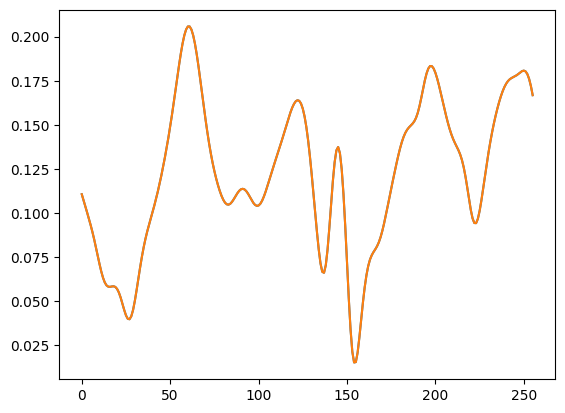

In [163]:
model = ContextFNO(5,10,5).to(device)
model.eval()
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[0:1,:,:50,0].unsqueeze(-1).to(device)
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
plt.plot((model.forward(X,xl)).squeeze().detach().cpu())
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[0:1,:,:50,0].unsqueeze(-1).to(device)
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
plt.plot((model.forward(X,xl)).squeeze().detach().cpu())

In [138]:
model = ContextFNO(16,64,5).to(device)

In [12]:
import pickle


with open(file='trained_model_attein.pickle', mode='wb') as f:
    pickle.dump(model, f)

In [13]:
torch.save(model.state_dict(), "contextfno_state_atteion.pth")

In [ ]:
model = ContextFNO(8,4,8,16,3).to(device)
model.load_state_dict(torch.load("contextfno_state_22.pth", map_location=device))

In [ ]:
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[1:2,:,:50,0].unsqueeze(-1).to(device)
y = []
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
model.to(device)
f0 = model.forward(X,xl)
f1 = model.forward(X,xr)
        
for i in range(20):

    x = x +(0.256)/5*(f0-f1)
    #y.append(x)
    xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
    xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
    
    
    f0 = model.forward(X,xl)
    f1 = model.forward(X,xr)
            


KeyboardInterrupt



In [30]:
j = 1
x = XX[5*j:5*(j+1)]
consi = consiI[5*j:5*(j+1)]
model.train()
t1 = default_timer()
train_mse = 0
train_l2 = 0
train_l2_2 = 0


xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=3)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=3)

f0 = model.train_forward(x,xl)

NameError: name 'model' is not defined

In [102]:
dataset[:2,:,0,0].unsqueeze(-1).to(device).shape

torch.Size([2, 256, 1])

In [103]:
dataset[:1,:,:,0].unsqueeze(-1).to(device).shape

torch.Size([1, 256, 50, 1])

In [152]:
((torch.sum(XX, dim=3).unsqueeze(2)).permute(0, 3, 1, 2).flatten(start_dim=0, end_dim=1)).shape

torch.Size([5000, 256, 1])

In [155]:
torch.sum(XX, dim=2).unsqueeze(2).shape

torch.Size([100, 256, 1, 1])

In [156]:
XX.shape

torch.Size([100, 256, 50, 1])

In [121]:
X.shape

torch.Size([1, 20, 20, 1])

In [147]:
model.eval()  # 드롭아웃/BN 고정
NNN = 4
with torch.inference_mode():  # 또는 torch.no_grad()
    x = dataset[NNN:NNN+1,:,0,0].unsqueeze(-1).to(device).detach()
    X = dataset[NNN:NNN+1,:,:5,0].unsqueeze(-1).to(device).detach()

    xl = torch.cat((torch.roll(x, -2, dims=1),
                    torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1)), dim=2)
    xr = torch.cat((torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1),
                    torch.roll(x, 2, dims=1)), dim=2)

    f0 = model.forward(X, xl)  # model.forward(...) 대신 호출 권장
    f1 = model.forward(X, xr)

    for _ in range(50):
        # in-place로 조금 더 절약 가능 (inference_mode에서는 안전)
        x = x + (0.128) * (f0 - f1)

        xl = torch.cat((torch.roll(x, -2, dims=1),
                        torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1)), dim=2)
        xr = torch.cat((torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1),
                        torch.roll(x, 2, dims=1)), dim=2)

        f0 = model.forward(X, xl)
        f1 = model.forward(X, xr)

In [27]:
model.eval()  # 드롭아웃/BN 고정
NNN = 2
with torch.inference_mode():  # 또는 torch.no_grad()
    x = testset[NNN:NNN+1,:,0,0].unsqueeze(-1).to(device).detach()
    X = testset[NNN+1:NNN+2,:,0:5,0].unsqueeze(-1).to(device).detach()

    xl = torch.cat((torch.roll(x, -2, dims=1),
                    torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1)), dim=2)
    xr = torch.cat((torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1),
                    torch.roll(x, 2, dims=1)), dim=2)

    f0 = model.forward(X, xl)  # model.forward(...) 대신 호출 권장
    f1 = model.forward(X, xr)

    for _ in range(50):
        # in-place로 조금 더 절약 가능 (inference_mode에서는 안전)
        x = x + (0.128) * (f0 - f1)

        xl = torch.cat((torch.roll(x, -2, dims=1),
                        torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1)), dim=2)
        xr = torch.cat((torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1),
                        torch.roll(x, 2, dims=1)), dim=2)

        f0 = model.forward(X, xl)
        f1 = model.forward(X, xr)

In [13]:
x = testset[:2,:,:,0].unsqueeze(-1).to(device)

y = []
xl = torch.cat((x, torch.roll(x, -1, dims = 1)),dim=3)
xr = torch.cat((x, torch.roll(x, 1, dims = 1)),dim=3)

f0 = model.train_forward(x,xl)
f1 = model.train_forward(x,xr)
        
for i in range():

    x = x -(0.256)/5*(f0-f1)
    #y.append(x)
    xl = torch.cat((x, torch.roll(x, -1, dims = 1)),dim=3)
    xr = torch.cat((x, torch.roll(x, 1, dims = 1)),dim=3)
    
    f0 = model.train_forward(X,xl)
    f1 = model.train_forward(X,xr)
            

AttributeError: 'ContextFNO' object has no attribute 'train_forward'

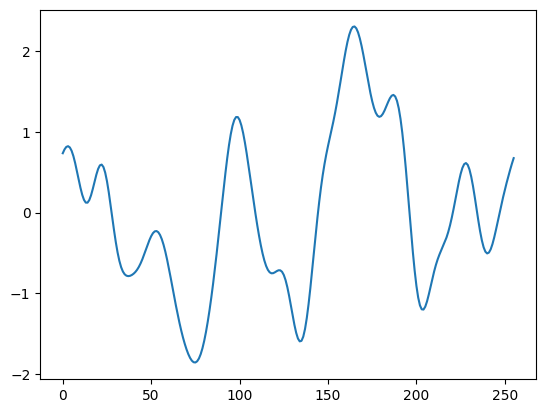

In [33]:
plt.plot(testset.detach().cpu()[0,:,0,0])

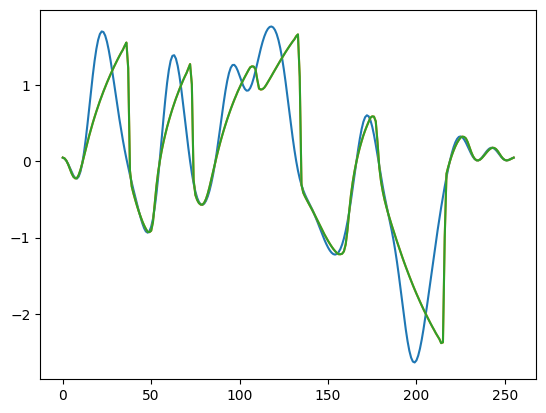

In [148]:
M = 0
plt.plot(dataset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(dataset.detach().cpu()[NNN,:,50,0])

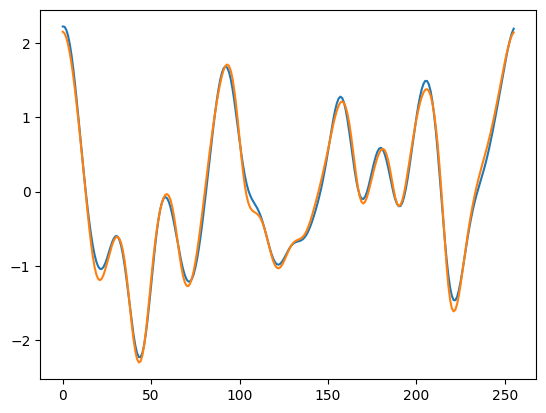

In [26]:
M = 0
plt.plot(testset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
#plt.plot(testset.detach().cpu()[NNN,:,50,0])

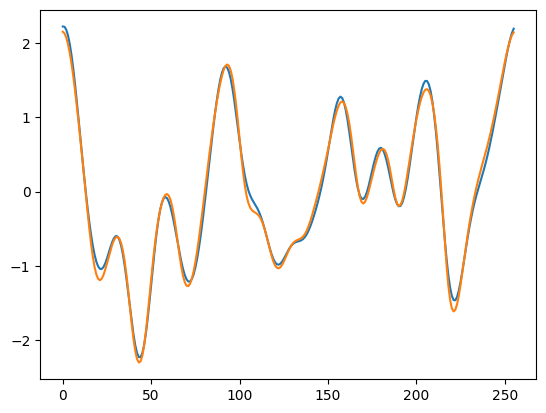

In [28]:
M = 0
plt.plot(testset.detach().cpu()[NNN,:,0,0])
plt.plot(x.detach().cpu()[0,:,0])
#plt.plot(testset.detach().cpu()[NNN,:,50,0])

## x

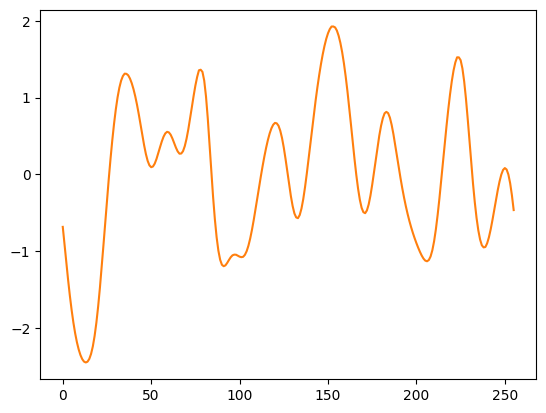

In [19]:


#plt.plot(x[0].detach().cpu()+ 0.256/5*(f0[0,:,:]-f1[0,:,:]).detach().cpu())
#plt.plot(X[0,:,0,:].detach().cpu())
plt.plot(x[0].detach().squeeze().cpu())
plt.plot(X[0,:,99,:].detach().cpu())

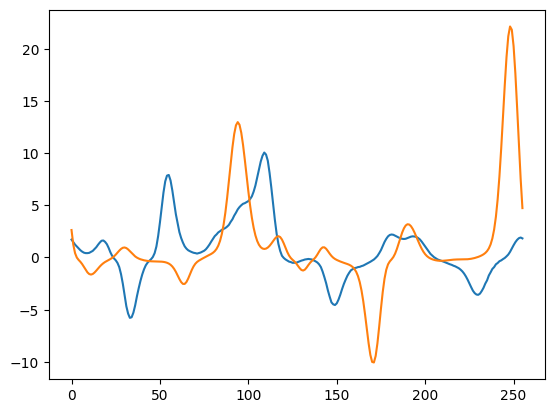

In [21]:
plt.plot(MM.detach().cpu()[0,:,0,0])
plt.plot(dataset[:,:,:,1].unsqueeze(-1).detach().cpu()[0,:,0,0])

In [ ]:
plt.plot(dataset[:10,:,:,0].unsqueeze(-1).detach().cpu()[0,:,1,0]-dataset[:10,:,:,0].unsqueeze(-1).detach().cpu()[0,:,0,0])

In [129]:
"""
All-in-one: Stable Context Attention Encoder + Positional Encoding + Pooling Options + Diagnostics

What you get in this single file
- build_nd_posenc: Fourier N-D positional encoding that matches your original signature
- LearnedPos: fallback learned positional embedding (robust)
- AttnPool: attention-based pooling to avoid mean-pooling collapse
- ContextAttentionEncoder: drop-in, configurable (posenc='auto'|'fourier'|'learned', pool='attn'|'cls'|'mean'|'meanmax')
- StableContextEncoder: minimal, rock-solid baseline to compare against
- Diagnostics: quick_probe, register_std_probes/run_probe, bisect_variance, fingerprint
- Training helper: make_optimizer with no_decay grouping for norms/bias/pos/gates

Usage sketch (see bottom for quick self-test):
    model = ContextAttentionEncoder(posenc='auto', pool='attn')
    x = torch.randn(8, 8, 8, 32)  # [B, D1, D2, ..., C]
    z = model(x)

"""

from typing import Tuple, List
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------
# Positional Encodings
# ------------------------------

def build_nd_posenc(spatial: Tuple[int, ...], device, num_freqs: int = 8, use_sincos: bool = True) -> torch.Tensor:
    """
    Fourier N-D positional encoding compatible with your original call.
    Returns: [1, N, P] where N = prod(spatial), P = (2 * num_freqs * ndim) [+ ndim if not use_sincos]
    - Coordinates are normalized to [0,1].
    - Frequencies are powers of 2: 2^k * pi.
    """
    assert len(spatial) >= 1, "Need at least 1 spatial dimension"
    grids = [torch.linspace(0.0, 1.0, s, device=device) for s in spatial]
    mesh = torch.meshgrid(*grids, indexing='ij')  # list of [d1,...,dn]
    coords = [m.reshape(-1, 1) for m in mesh]     # each [N,1]
    N = coords[0].shape[0]
    ndim = len(spatial)

    if use_sincos:
        feats = []
        for d in range(ndim):
            c = coords[d]  # [N,1]
            for k in range(num_freqs):
                freq = (2.0 ** k) * math.pi
                feats.append(torch.sin(c * freq))  # [N,1]
                feats.append(torch.cos(c * freq))  # [N,1]
        out = torch.cat(feats, dim=1)  # [N, 2*num_freqs*ndim]
    else:
        out = torch.cat(coords, dim=1)  # [N, ndim]

    return out.unsqueeze(0)  # [1, N, P]


class LearnedPos(nn.Module):
    """Learned positional embedding that adapts to N=prod(spatial)."""
    def __init__(self, d_model: int):
        super().__init__()
        self.pe: torch.nn.Parameter | None = None
        self.d = d_model

    def forward(self, spatial: Tuple[int, ...], B: int, device) -> torch.Tensor:
        N = int(torch.tensor(spatial, device=device).prod())
        if (self.pe is None) or (self.pe.shape[1] != N) or (self.pe.device != device):
            self.pe = nn.Parameter(torch.zeros(1, N, self.d, device=device))
            nn.init.trunc_normal_(self.pe, std=0.02)
        return self.pe.expand(B, -1, -1)  # [B, N, d]


# ------------------------------
# Pooling
# ------------------------------

class AttnPool(nn.Module):
    """Single learned query attends over tokens to produce a pooled vector."""
    def __init__(self, d_model: int, nhead: int = 4):
        super().__init__()
        self.query = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.query, std=0.02)
        self.attn = nn.MultiheadAttention(d_model, max(1, nhead), batch_first=True)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        # h: [B, N, d]
        B = h.size(0)
        q = self.query.expand(B, 1, -1)  # [B,1,d]
        out, _ = self.attn(q, h, h, need_weights=False)  # [B,1,d]
        return out[:, 0, :]  # [B,d]


# ------------------------------
# Encoders
# ------------------------------

class ContextAttentionEncoder(nn.Module):
    """
    Drop-in, configurable encoder.
    - posenc: 'auto'|'fourier'|'learned'
        * 'auto': try Fourier; if it collapses, you can switch to 'learned' without other changes
    - pool: 'attn'|'cls'|'mean'|'meanmax'
        * 'attn' (default) avoids mean-pooling flatness
    - use_cls: still supported; for pool='cls' it uses the prepended token
    """
    def __init__(self, d_model=256, nhead=8, num_layers=4, dim_ff=1024,
                 out_dim=128, num_freqs=8, use_cls=True, dropout=0.1,
                 posenc: str = 'auto', pool: str = 'attn', pos_gate_init: float = 1.0):
        super().__init__()
        assert posenc in {'auto', 'fourier', 'learned'}
        assert pool in {'attn', 'cls', 'mean', 'meanmax'}
        self.use_cls = use_cls
        self.num_freqs = num_freqs
        self.posenc_kind = posenc
        self.pool_kind = pool

        # Content projection (Lazy to infer input channels at runtime)
        self.in_proj = nn.LazyLinear(d_model, bias=True)

        # Positional components
        if posenc in {'auto', 'fourier'}:
            self.pos_proj = nn.LazyLinear(d_model, bias=False)  # pos -> d_model
            # gated scale; make it strictly positive via softplus during forward
            self.pos_scale = nn.Parameter(torch.tensor(float(pos_gate_init)))  # raw; softplus in forward
        if posenc in {'auto', 'learned'}:
            self.learned_pos = LearnedPos(d_model)

        # Encoder (no extra pre-LN; layers are norm_first=True already)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers, norm=nn.LayerNorm(d_model))

        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Pooling
        if pool == 'attn':
            self.pool = AttnPool(d_model, nhead=max(1, nhead // 2))
            head_in = d_model
        elif pool == 'cls':
            self.pool = None
            head_in = d_model
        elif pool == 'mean':
            self.pool = None
            head_in = d_model
        elif pool == 'meanmax':
            self.pool = None
            head_in = 2 * d_model
        else:
            raise ValueError("Unknown pool kind")

        # Head
        self.head = nn.Sequential(
            nn.Linear(head_in, d_model), nn.GELU(),
            nn.Linear(d_model, out_dim)
        )
        # Init head
        nn.init.xavier_uniform_(self.head[0].weight); nn.init.zeros_(self.head[0].bias)
        nn.init.xavier_uniform_(self.head[2].weight); nn.init.zeros_(self.head[2].bias)

    @staticmethod
    def _softplus_pos(x: torch.Tensor) -> torch.Tensor:
        return F.softplus(x) + 1e-4

    def _make_pos(self, spatial: Tuple[int, ...], B: int, device) -> torch.Tensor:
        """Return position embedding aligned to d_model, shape [B, N, d_model]."""
        if self.posenc_kind in {'auto', 'fourier'}:
            pos_raw = build_nd_posenc(spatial, device, num_freqs=self.num_freqs, use_sincos=True)  # [1,N,P]
            pos = self.pos_proj(pos_raw.expand(B, -1, -1))  # [B,N,d]
            pos = self._softplus_pos(self.pos_scale) * pos
        else:
            pos = self.learned_pos(spatial, B, device)
        return pos

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, D1, D2, ..., C]
        returns: [B, out_dim]
        """
        B, *spatial, C = x.shape
        device = x.device
        xtok = x.reshape(B, -1, C)                 # [B, N, C]

        h = self.in_proj(xtok)                     # [B, N, d]
        pos = self._make_pos(tuple(spatial), B, device)  # [B, N, d]
        h = h + pos                                 # inject position

        if self.use_cls:
            cls = self.cls_token.expand(B, 1, -1)  # [B,1,d]
            h = torch.cat([cls, h], dim=1)         # [B,1+N,d]

        h = self.encoder(h)                         # [B,1+N,d] or [B,N,d]

        if self.pool_kind == 'attn':
            if self.use_cls:
                tokens = h[:, 1:, :]  # exclude CLS to avoid trivial shortcut
            else:
                tokens = h
            pooled = self.pool(tokens)              # [B,d]
        elif self.pool_kind == 'cls' and self.use_cls:
            pooled = h[:, 0, :]
        elif self.pool_kind == 'mean':
            if self.use_cls:
                pooled = h[:, 1:, :].mean(dim=1)
            else:
                pooled = h.mean(dim=1)
        elif self.pool_kind == 'meanmax':
            if self.use_cls:
                toks = h[:, 1:, :]
            else:
                toks = h
            pooled = torch.cat([toks.mean(dim=1), toks.amax(dim=1)], dim=-1)
        else:
            raise ValueError("Pooling configuration invalid for current settings.")

        z = self.head(pooled)
        return z


def downsample_along_Nd(x, Nd_max=512):
    """
    x: [B, N_d, N_t, C] (채널 마지막)
    반환: [B, N_d', N_t, C]  where N_d' = min(N_d, Nd_max)
    분산 보존을 위해 sqrt(N_d / N_d')로 게인 보정
    """
    B, Nd, Nt, C = x.shape
    if Nd_max is None or Nd <= Nd_max:
        return x
    flat = x.reshape(B, Nd, Nt*C).transpose(1, 2)            # [B, Nt*C, Nd]
    ds   = F.adaptive_avg_pool1d(flat, Nd_max).transpose(1, 2)  # [B, Nd', Nt*C]
    gain = math.sqrt(Nd / float(Nd_max))
    ds   = (ds * gain).reshape(B, Nd_max, Nt, C)
    return ds



class AttnPool(nn.Module):
    def __init__(self, d_model, nhead=4):
        super().__init__()
        self.query = nn.Parameter(torch.zeros(1,1,d_model))
        nn.init.trunc_normal_(self.query, std=0.02)
        self.attn  = nn.MultiheadAttention(d_model, max(1, nhead), batch_first=True)
        # ★ log-scale(배율=exp(s)): N 커져도 예리함 유지
        self.logit_logscale = nn.Parameter(torch.tensor(0.0))  # init=0 => scale=1.0

    def forward(self, h):  # h: [B, N, d]
        B = h.size(0)
        q = self.query.expand(B,1,-1) * self.logit_logscale.exp()   # ← 로짓 스케일 업
        out, _ = self.attn(q, h, h, need_weights=False)
        return out[:,0,:]


def set_attn_scale_for_length(module, N, base=1.0):
    # 원하는 N에서 scale≈base*log(N)
    with torch.no_grad():
        module.logit_logscale.copy_(torch.tensor(math.log(base * math.log(N+1))))

        
class StableContextEncoder(nn.Module):
    """A minimal, highly stable variant for sanity checking."""
    def __init__(self, d_model=256, nhead=4, num_layers=2, dim_ff=1024,
                 out_dim=128, dropout=0.1):
        super().__init__()
        self.in_proj = nn.LazyLinear(d_model)
        self.pos     = LearnedPos(d_model)
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=dim_ff,
            batch_first=True, dropout=dropout, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers, norm=nn.LayerNorm(d_model))
        self.pool    = AttnPool(d_model, nhead=max(1, nhead // 2))
        self.head    = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(), nn.Linear(d_model, out_dim))
        for i in [0, 2]:
            nn.init.xavier_uniform_(self.head[i].weight); nn.init.zeros_(self.head[i].bias)
        self.cls_token = None  # not used here

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, *spatial, C = x.shape
        dev = x.device
        xtok = x.reshape(B, -1, C)
        h = self.in_proj(xtok) + self.pos(tuple(spatial), B, dev)
        h = self.encoder(h)
        pooled = self.pool(h)
        return self.head(pooled)


# ------------------------------
# Diagnostics & Probes
# ------------------------------

def quick_probe(model: nn.Module, x: torch.Tensor):
    """Print basic std statistics through the forward path."""
    model.eval()
    with torch.no_grad():
        B, *spatial, C = x.shape
        xtok = x.reshape(B, -1, C)
        print(f"[x] global std: {xtok.std().item():.6f}")
        # pos raw
        if hasattr(model, '_make_pos'):
            pos = model._make_pos(tuple(spatial), B, x.device)
            print(f"[pos] std: {pos.std().item():.6f}")
        hx = model.in_proj(xtok)
        print(f"[in_proj(x)] std: {hx.std().item():.6f}")
        if hasattr(model, '_make_pos'):
            hp = hx + model._make_pos(tuple(spatial), B, x.device)
            print(f"[in+pos] std: {hp.std().item():.6f}")
        z = model(x)
        print(f"[model(z)] std: {z.std().item():.6f}")


def register_std_probes(model: nn.Module):
    """Attach forward hooks to capture std at major modules; returns handles to remove later."""
    probes = []
    stats_key = '_stats'
    def hook(name):
        def fn(mod, inp, out):
            t = out if isinstance(out, torch.Tensor) else out[0]
            model.__dict__.setdefault(stats_key, {})[name] = float(t.detach().std())
        return fn

    if hasattr(model, 'in_proj'): probes.append(model.in_proj.register_forward_hook(hook('in_proj')))
    if hasattr(model, 'pos_proj'): probes.append(model.pos_proj.register_forward_hook(hook('pos_proj')))
    if hasattr(model, 'pool') and isinstance(model.pool, nn.Module):
        probes.append(model.pool.register_forward_hook(hook('pool_in')))
    # Encoder layers
    enc = getattr(model, 'encoder', None)
    if enc is not None and hasattr(enc, 'layers'):
        for i, layer in enumerate(enc.layers):
            probes.append(layer.register_forward_hook(hook(f'enc[{i}]')))
    # Head
    probes.append(model.head.register_forward_hook(hook('head_in')))
    return probes


def run_probe(model: nn.Module, x: torch.Tensor):
    """Run a forward pass with hooks and estimate input sensitivity (grad std)."""
    model.eval()
    probes = register_std_probes(model)
    try:
        with torch.no_grad():
            z = model(x)
        stats = getattr(model, '_stats', {})
        stats['output_std'] = float(z.std())
        # sensitivity: d(sum z)/d x
        x_req = x.detach().clone().requires_grad_(True)
        z2 = model(x_req)
        z2.sum().backward()
        grad_std = float(x_req.grad.std()) if x_req.grad is not None else 0.0
        stats['d(output)/d(input)_std'] = grad_std
        return z, stats
    finally:
        for h in probes:
            h.remove()


def bisect_variance(model: nn.Module, x: torch.Tensor):
    """Report std after each logical step to localize collapse."""
    model.eval()
    with torch.no_grad():
        B, *spatial, C = x.shape
        xtok = x.reshape(B, -1, C)
        stats = {}
        h = model.in_proj(xtok); stats['in_proj(x)'] = h.std().item()
        if hasattr(model, '_make_pos'):
            h = h + model._make_pos(tuple(spatial), B, x.device)
            stats['+pos'] = h.std().item()
        if getattr(model, 'use_cls', False):
            h = torch.cat([model.cls_token.expand(B, 1, -1), h], dim=1)
            stats['+cls'] = h.std().item()
        cur = h
        enc = getattr(model, 'encoder', None)
        if enc is not None and hasattr(enc, 'layers'):
            for i, layer in enumerate(enc.layers):
                cur = layer(cur)
                stats[f'enc[{i}]'] = cur.std().item()
        # pooling
        if getattr(model, 'pool_kind', 'attn') == 'attn':
            toks = cur[:, 1:, :] if getattr(model, 'use_cls', False) else cur
            pooled = model.pool(toks)
        elif model.pool_kind == 'cls' and getattr(model, 'use_cls', False):
            pooled = cur[:, 0, :]
        elif model.pool_kind == 'mean':
            pooled = (cur[:, 1:, :].mean(dim=1) if getattr(model, 'use_cls', False) else cur.mean(dim=1))
        else:  # meanmax
            toks = cur[:, 1:, :] if getattr(model, 'use_cls', False) else cur
            pooled = torch.cat([toks.mean(dim=1), toks.amax(dim=1)], dim=-1)
        stats['pool'] = pooled.std().item()
        z = model.head(pooled); stats['head'] = z.std().item()
        return stats


def fingerprint(x: torch.Tensor) -> torch.Tensor:
    """Quick batch similarity fingerprint. If std≈0, your batch is effectively identical."""
    return torch.round(x.float().mean(dim=tuple(range(1, x.ndim))), decimals=4)


# ------------------------------
# Training helper (optimizer)
# ------------------------------

def make_optimizer(model: nn.Module, lr: float = 3e-4, weight_decay: float = 0.05) -> torch.optim.Optimizer:
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        name = n.lower()
        if name.endswith('bias') or ('norm' in name) or ('ln' in name) or ('pos' in name) or ('query' in name) or ('scale' in name):
            no_decay.append(p)
        else:
            decay.append(p)
    return torch.optim.AdamW(
        [
            {'params': decay, 'weight_decay': weight_decay},
            {'params': no_decay, 'weight_decay': 0.0},
        ], lr=lr, betas=(0.9, 0.95)
    )


# ------------------------------
# Quick self-test (optional)
# ------------------------------
if __name__ == '__main__':
    torch.manual_seed(0)
    B, D1, D2, C = 6, 8, 8, 32
    x = torch.randn(B, D1, D2, C)

    print("\n=== ContextAttentionEncoder (auto/attn) ===")
    model = ContextAttentionEncoder(out_dim=128, posenc='auto', pool='attn')
    z, stats = run_probe(model, x)
    print("stats:", stats)

    print("\n=== StableContextEncoder (baseline) ===")
    stable = StableContextEncoder(out_dim=128)
    z2, stats2 = run_probe(stable, x)
    print("stats:", stats2)

    print("\n=== Bisect Variance (ContextAttentionEncoder) ===")
    bstats = bisect_variance(model, x)
    for k, v in bstats.items():
        print(f"{k:>12s} : {v:.6f}")

    print("\n=== Batch fingerprint ===")
    fp = fingerprint(x)
    print("fp std:", fp.std().item())

    print("\n=== make_optimizer() demo ===")
    opt = make_optimizer(model)
    print(opt)



=== ContextAttentionEncoder (auto/attn) ===
stats: {'in_proj': 0.5884045362472534, 'pos_proj': 0.4038088619709015, 'enc[0]': 0.8131191730499268, 'enc[1]': 0.896416425704956, 'enc[2]': 1.0212997198104858, 'enc[3]': 1.1798683404922485, 'pool_in': 0.17500700056552887, 'head_in': 0.09962546080350876, 'output_std': 0.09962546080350876, 'd(output)/d(input)_std': 0.010470357723534107}

=== StableContextEncoder (baseline) ===
stats: {'in_proj': 0.5837916731834412, 'enc[0]': 0.6229066848754883, 'enc[1]': 0.7278105020523071, 'pool_in': 0.16827793419361115, 'head_in': 0.11497224122285843, 'output_std': 0.11497224122285843, 'd(output)/d(input)_std': 0.01071296725422144}

=== Bisect Variance (ContextAttentionEncoder) ===
  in_proj(x) : 0.588405
        +pos : 0.789290
        +cls : 0.783199
      enc[0] : 0.813119
      enc[1] : 0.896416
      enc[2] : 1.021300
      enc[3] : 1.179868
        pool : 0.209301
        head : 0.120801

=== Batch fingerprint ===
fp std: 0.020997999235987663

=== make